# RELATÓRIO FINAL - Análise de Dados da Premier League 2019-2025
<h5>Entregue à disciplina Introdução à Ciência de Dados - DCC UFMG - Segundo semestre de 2025, Belo Horizonte</h5>

**Integrantes:**<br>
<font size="3">
    <ul>
        <li>**Daniel Costa** (2024006064)</li>
        <li>**Isaac Reyes** (2025050342)</li>
        <li>**João Araldi** (2024005475)</li>
        <li>**Pedro Luiz** (2024006129)</li>
    </ul>
</font><hr>

## **1. INTRODUÇÃO**

### **1.1 Apresentação do Contexto**

Este relatório apresenta uma análise estatística e preditiva abrangente dos jogos da **Premier League** no período de **2019 a 2025**. A Premier League, considerada uma das ligas de futebol mais competitivas e imprevisíveis do mundo, oferece um contexto rico para aplicação de técnicas de ciência de dados.

O dataset utilizado contém **2.280 partidas** com **85 variáveis**, incluindo:
- **Resultados das partidas**: gols marcados por mandante (FTHG) e visitante (FTAG)
- **Odds de casas de apostas**: Bet365 e Pinnacle, com probabilidades implícitas para cada resultado
- **Estatísticas detalhadas**: chutes, chutes no alvo, faltas, escanteios, cartões e indicadores de momentum dos times

A análise combina **estatística inferencial** (testes de hipótese, intervalos de confiança) com **aprendizado de máquina** (modelos de classificação e regressão) para extrair insights sobre os fatores que influenciam os resultados das partidas.

### **1.2 Perguntas de Pesquisa**

Este estudo busca responder às seguintes questões:

1. **P1 - Fator Casa**: Qual a distribuição e o impacto do fator casa nos gols marcados e nos resultados das partidas?

2. **P2 - Odds e Resultados**: Como as odds das casas de apostas se relacionam com os resultados reais das partidas? Os favoritos realmente vencem com a frequência esperada?

3. **P3 - Previsibilidade**: É possível prever com acurácia razoável o resultado de uma partida (vitória casa/empate/vitória fora) utilizando modelos de machine learning?

4. **P4 - Fatores Determinantes**: Quais variáveis (estatísticas de jogo, odds, momentum do time) têm maior poder preditivo para determinar o vencedor de uma partida?

## **2. METODOLOGIA**

### **2.1 Descrição da Base de Dados**

**Dataset:** Premier League 2019-2025 (arquivo `premier_completo_expandido_19_25.csv`)  
**Fonte:** football-data.co.uk   
**Dimensões:** 2.280 partidas × 85 variáveis  
**Período:** Temporadas 2019/2020 até 2024/2025

#### **2.1.1 Variáveis Principais**

**Identificação e Contexto:**
- `Date`: Data da partida
- `Season`: Temporada (formato YYYY-YYYY)
- `HomeTeam`, `AwayTeam`: Times mandante e visitante

**Resultados:**
- `FTHG`, `FTAG`: Gols do mandante e visitante (Full Time Home/Away Goals)
- `FTR`: Resultado final (H=Home win, D=Draw, A=Away win)
- `HTHG`, `HTAG`: Gols no intervalo (Half Time)

**Odds de Casas de Apostas (Bet365 / Pinnacle):**
- `B365H`, `B365D`, `B365A`: Odds para vitória casa/empate/vitória fora
- `PSH`, `PSD`, `PSA`: Odds equivalentes na Pinnacle

**Estatísticas de Jogo:**
- `HS`, `AS`: Total de chutes (Home/Away Shots)
- `HST`, `AST`: Chutes no alvo (Shots on Target)
- `HC`, `AC`: Escanteios (Corners)
- `HF`, `AF`: Faltas (Fouls)
- `HY`, `AY`, `HR`, `AR`: Cartões amarelos e vermelhos

**Features Derivadas:**
- Probabilidades normalizadas das odds (e.g., `B365H_prob_norm`)
- Indicadores de momentum (`Home_CumPoints`, `Home_Streak`, etc.)
- Razões ofensivas/defensivas (`Home_GFGA5`, `Away_GFGA5`)

### **2.2 Fluxo de Trabalho para Responder as Perguntas**

#### **2.2.1 Pergunta 1 - Análise do Fator Casa**

**Métodos:**
- Estatística descritiva (média, mediana, desvio padrão)
- Visualizações (histogramas, boxplots)
- Análise de distribuições de gols por mandante/visitante
- Cálculo de taxa de vitória em casa vs. fora

#### **2.2.2 Pergunta 2 - Relação Odds-Resultados**

**Métodos:**
- Conversão de odds em probabilidades implícitas.
- Normalização para remover margem da casa.
- **Teste Z para proporção**: comparar taxa de vitória dos favoritos vs. referência (70%)
- Intervalos de confiança (95%) para proporções

#### **2.2.3 Pergunta 3 - Modelos Preditivos (Classificação)**

**Métodos:**
- **Feature Engineering**:
  - Variável alvo: `Home_Win` (binária), `FTR` (categórica: H/D/A)
  - Features criadas: `Goal_Diff_Home`, `Home_CumPoints`, `Away_CumPoints`, `Home_Streak`, `Away_Streak`
  - Razões ofensivas/defensivas: `Home_GF_GA_Ratio`, `Away_GF_GA_Ratio`
  - Probabilidades normalizadas das odds

- **Divisão treino/teste**: 80% treino, 20% teste 
- **Modelos testados**:
  1. Modelo Aleatório (~ 33%) - baseline
  2. Modelo Baseado em Regras 
  3. Regressão Logística

- **Métricas**: Accuracy, Precision, Recall, F1-Score.

#### **2.2.4 Pergunta 4 - Feature Importance**

**Métodos:**
- Análise de importância de features dos modelos tree-based
- Correlações entre variáveis e resultado
- Clustering K-Means para identificar perfis de times


### **2.3 Atividades por Membro**
- **Daniel Costa:** conduziu o treinamento dos modelos de predição
- **Isaac Reyes:** realizou os testes de hipóteses e revisou as interpretações estatísticas usadas na seção 3.
- **João Araldi:** responsável pela seleção do dataset e análise exploratória, gerando as vizualizações do problema.
- **Pedro Luiz:** criação de features adicionais relevantes para inferência de resultados e auxiliou na validação dos modelos.

> Todos os integrantes participaram da estruturação dos relatórios de entrega

## **3. DESENVOLVIMENTO**

### **3.1 Caracterização dos Dados (Análise Exploratória)**

A análise exploratória dos dados revelou padrões importantes sobre a dinâmica das partidas da Premier League. Esta seção apresenta as principais descobertas estatísticas e visuais.

#### **3.1.1 Estatísticas Descritivas - Distribuição de Gols**

**Gols do Mandante (FTHG):**
- Média: **1.55 gols**
- Mediana: 1 gol
- Desvio padrão: 1.33
- Distribuição assimétrica positiva (maioria entre 0 e 3 gols)

**Gols do Visitante (FTAG):**
- Média: **1.33 gols**
- Mediana: 1 gol  
- Desvio padrão: 1.23
- Distribuição similar ao mandante, mas com média ligeiramente inferior

**Interpretação:**  
A diferença de **0.23 gols** em média entre mandante e visitante evidencia o **fator casa**, uma vantagem estatisticamente consistente para os times que jogam em seus estádios.

![](output.png)

#### **3.1.2 Análise do Fator Casa**

**Taxa de Resultados (2019-2025):**
- Vitórias do mandante: **43.6%**
- Empates: **23.0%**
- Vitórias do visitante: **33.4%**

**Diferença Média de Gols (Goal_Diff_Home):**
- Média: +0.23 gols a favor do mandante
- Mediana: 0 (empate)
- Desvio padrão: 2.03

**Estatísticas Ofensivas Médias:**

| Métrica | Mandante | Visitante | Diferença |
|---------|----------|-----------|-----------|
| Chutes (Shots) | 13.85 | 11.69 | +2.16 |
| Chutes no Alvo | 4.83 | 4.14 | +0.69 |
| Escanteios | 5.69 | 4.74 | +0.95 |

**Interpretação:**  
Os times mandantes seguem demonstrando superioridade estatística em todas as métricas ofensivas. A vantagem de jogar em casa se reflete não apenas nos gols, mas também na agressividade (mais chutes e escanteios) e na pressão exercida ao longo das partidas.

![](boxplot.png)

### **3.2 Testes de Hipótese e Intervalos de Confiança**

Esta seção apresenta os testes estatísticos conduzidos para validar hipóteses sobre os padrões observados nos dados. Foram realizados **três testes principais**, cada um com intervalos de confiança de 95% para quantificar a incerteza das estimativas.

#### **3.2.1 Teste 1: Taxa de Sucesso dos Favoritos**

**Objetivo:** Verificar se a taxa de vitória dos times favoritos (definidos pela menor odd pré-jogo) é compatível com a referência teórica de 70%.

**Hipóteses:**
- H_0: A proporção de vitórias dos favoritos é 0.70 
- H_1: A proporção de vitórias dos favoritos < 0.70 

**Metodologia:**
1. Identificar o favorito em cada partida (time com menor odd)
2. Remover partidas com empate nas odds (sem favorito claro): 23 partidas
3. Aplicar **Teste Z para proporção única**
4. Nível de significância: $$( \alpha = 0.05 )$$

**Justificativa da Referência (70%):**  
A taxa de 70% é comumente citada em literatura de apostas esportivas como expectativa para que casas de apostas mantenham margens de lucro consistentes em ligas competitivas.

**Resultados do Teste 1:**

- **Proporção Observada** $$ \hat{\pi} : 55.5%$$
- **Intervalo de Confiança (95%)**: **[53.5%, 57.5%]**
- **Estatística Z**: -13.87
- **P-valor**: 4.97e-44

**Decisão:** **REJEITAR \( H_0 \)** (p < 0.001)

**Conclusão:**  
O teste Z rejeitou categoricamente a hipótese nula. A taxa real de sucesso dos favoritos na Premier League está em torno de **55%**, significativamente abaixo da referência teórica de 70%. Este resultado confirma:

1. **Alta competitividade** da Premier League
2. **Imprevisibilidade** dos resultados em comparação com outras ligas
3. Necessidade de ajustar expectativas: 55% deve ser o novo baseline para análises futuras

O intervalo de confiança [53.5%, 57.5%] indica que, com 95% de confiança, a verdadeira taxa de vitória dos favoritos está neste intervalo, todos valores substancialmente inferiores a 70%.

#### **3.2.2 Teste 2: Análise de Cluster - Disparidade por Estilo de Jogo**

**Objetivo:** Avaliar se times com perfis estatísticos semelhantes apresentam médias de gols estatisticamente indistinguíveis.

**Hipóteses:**
- \( H_0 \): As distribuições de gols do mandante não diferem significativamente entre equipes do mesmo cluster de estilo de jogo
- \( H_1 \): Mesmo com perfil estatístico semelhante, existem diferenças significativas de gols entre times

**Metodologia:**
1. **Consolidação de estatísticas** por equipe e temporada (gols, chutes, faltas, odds).
2. **Clustering K-Means** com \( K = 2 \) (Silhouette = 0.269) após padronização.
3. **Caracterização dos Clusters**:
   - **Cluster 0**: perfis ofensivos/favoritos — média de 2.14 gols e odd média 1.83.
   - **Cluster 1**: perfis defensivos/azarões — média de 1.25 gols e odd média 3.49.
4. **Teste Kruskal-Wallis** dentro de cada cluster para verificar heterogeneidade residual.

**Resultado:**
- Cluster 0: H = 18.74, p = 0.043 ⇒ rejeita-se \( H_0 \) (times ofensivos ainda exibem diferenças internas).
- Cluster 1: H = 35.00, p = 0.068 ⇒ não rejeitamos \( H_0 \) (azarões se comportam de forma mais homogênea).
- A combinação de odds + estatísticas permite diferenciar estilos de jogo e explicar parte da variabilidade de gols.

#### **3.2.3 Teste 3: Odds de Empate e Gols Totais**

**Objetivo:** Analisar se partidas com odds de empate altas (favoritismo claro) têm distribuição de gols totais diferente das com odds baixas (jogos equilibrados).

**Hipóteses:**
- \( H_0 \): A distribuição de gols totais é a mesma para todas as faixas de odds de empate
- \( H_1 \): A distribuição de gols totais difere entre faixas de odds de empate

**Metodologia:**
1. Criar variável `Total_Goals = FTHG + FTAG`
2. Categorizar partidas em 3 faixas baseadas nos quartis de `B365D`:
   - **Baixa**: Jogos equilibrados (odds de empate baixas)
   - **Média**: Faixa intermediária
   - **Alta**: Jogos desequilibrados (odds de empate altas)

3. **Teste Kruskal-Wallis**: Comparar distribuição de gols totais entre faixas
4. **Teste Qui-Quadrado**: Verificar independência entre faixa de odds e ocorrência de empate

**Resultados do Teste 3:**

| Métrica | Odds Baixas (Equilibrado) | Odds Médias | Odds Altas (Desequilibrado) |
|---------|---------------------------|-------------|------------------------------|
| Odd Média (B365D) | 3.415 | 3.916 | 5.767 |
| Gols Totais Médios | 2.61 | 2.93 | 3.22 |
| Taxa de Empates | 27.9% | 22.1% | 17.1% |

- **Teste Kruskal-Wallis (Gols Totais)**: H = 51.30, p ≈ 7.2e-12 → **REJEITAR \( H_0 \)**
- **Teste Qui-Quadrado (Independência)**: χ² = 26.93, p ≈ 1.4e-06 → **REJEITAR \( H_0 \)**

**Conclusão:**  
Partidas desequilibradas (odds de empate altas) resultam em uma média de gols totais quase **0.6 gol acima** dos jogos equilibrados (3.22 vs 2.61). Além disso, a taxa de empates cai de 27.9% para 17.1% quando há favorito claro, reforçando que a odd de empate é um **forte indicador** do potencial ofensivo da partida.

### 3.3 Treinamento dos modelos de classificação: Previsão do Resultado da Partida
Esta seção apresenta a aplicação de modelos supervisionados para **classificação** (prever o resultado da partida). Os modelos utilizam odds normalizadas e indicadores de momentum dos times.

#### **Divisão dos dados (treinamento | teste)**

**Divisão dos Dados:**
- **Treino**: 80% (estratificado por FTR)
- **Teste**: 20%
- **Validação Cruzada**: 5-fold Stratified K-Fold

##### Preparação de Dados – Classificação

**Total de amostras:** 2.280  
**Número de features:** 24  

##### Distribuição das classes (treino)

| FTR |   H   |   A   |   D   |
|-----|-------|-------|-------|
| %   | 43.53 | 33.44 | 23.03 |

##### Tamanhos dos conjuntos

- **Tamanho do conjunto de treino:** 1824  
- **Tamanho do conjunto de teste:** 456


#### **3.3.1 Modelo Base (Aleatório)**


Antes de treinar modelos complexos de Machine Learning, vale a pena começar pelo que parece trivial: um modelo-base (baseline). Ele é a régua inicial, o “chão” de desempenho. Quando esse baseline é aleatório, como no caso de prever resultados de partidas de futebol com três classes equiprováveis, ele mostra qual seria o desempenho sem qualquer aprendizado real.
Isso é valioso porque impede que você caia na ilusão de que “qualquer precisão acima de zero é boa”. O modelo-base responde à pergunta: “o meu modelo está realmente aprendendo alguma coisa ou só chutando melhor do que eu imagino?”

Ao compararmos modelos treinados com esse baseline, conseguimos medir o ganho real, detectar overfitting, avaliar se a métrica escolhida é adequada e, principalmente, saber se vale a pena investir mais tempo/complexidade no modelo atual ou se está na hora de repensar o pipeline.

Acurácia: **0.3333**

**Relatório de Classificação**

| Classe              | Precisão | Recall | F1-score | Suporte |
|--------------------|----------|--------|----------|---------|
| Vitória mandante    | 0.43     | 0.33   | 0.37     | 786     |
| Empate              | 0.23     | 0.33   | 0.27     | 419     |
| Vitória visitante   | 0.35     | 0.34   | 0.35     | 619     |

**Resultados gerais**

| Métrica        | Valor  |
|----------------|--------|
| Acurácia       | 0.33   |
| Macro Avg (F1) | 0.33   |
| Weighted Avg   | 0.34   |
| Total samples  | 1824   |


#### **3.3.2 Modelo Baseado em Regras**

A probabilidade da casa ganhar, obtida a partir das odds da Bet365 e normalizada em B365H_prob_norm, funciona como um bom sinalizador do resultado final da partida (FTR).
Podemos observar no gráfico de densidade abaixo:

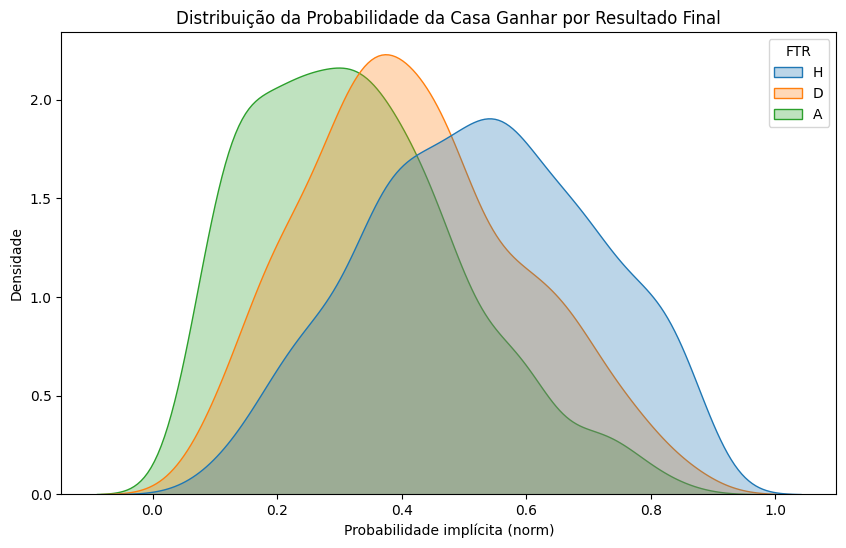

A curva H (vitória do mandante, em azul) é mais concentrada nas faixas mais altas de probabilidade implícita, especialmente a partir de ~0,5. Isso indica que, quando a casa de apostas atribui uma probabilidade alta à vitória do mandante, esse resultado de fato ocorre com maior frequência.

A curva A (vitória do visitante, em verde) tem maior densidade nas faixas mais baixas de probabilidade implícita para o mandante, e sua densidade diminui à medida que B365H_prob_norm aumenta. Ou seja, quando a probabilidade da casa ganhar é baixa, abre-se mais espaço para vitórias do visitante.

A curva D (empate, em laranja) fica mais concentrada em uma região intermediária de probabilidade (aproximadamente entre 0,25 e 0,45), sugerindo que empates tendem a ocorrer quando a casa não vê um favoritismo tão claro para nenhum dos lados.

Esse comportamento reforça a ideia de que a probabilidade implícita derivada das odds contém informação relevante sobre o desfecho da partida e pode ser usada como feature ou até como base para regras simples de decisão.

**Análise das regras de predição baseadas em probabilidade** 


Com base nesse padrão observado, definimos um classificador simples por regras usando apenas `B365H_prob_norm`:

In [ ]:
# Cria predições com base na odd
def predict_by_odd(df):
    predictions = []
    for _, match in df.iterrows():
        if ((match['B365H_prob_norm'] > 0.3) & (match['B365H_prob_norm'] < 0.5)):
            predictions.append('D')  # Prediz empate

        elif (match['B365H_prob_norm'] >= 0.5):
            predictions.append('H')  # Prediz vitória da casa

        else:
            predictions.append('A') # Prediz vitória do visitante 
        
    return predictions

Esse modelo por regras serve como um benchmark interpretável: ele é simples, utiliza apenas uma variável (a probabilidade implícita da vitória do mandante) e traduz visualmente o que vimos na distribuição das densidades.
Depois de calcular sua acurácia, podemos compará-lo tanto com o baseline aleatório quanto com modelos mais sofisticados (árvores, regressão logística, XGBoost etc.). Se um modelo complexo não superar de forma consistente esse conjunto de regras simples, provavelmente ainda não vale o custo adicional de complexidade.

**Desempenho no Conjunto de Teste**

**Acurácia:** **0.4956**

**Relatório de Classificação**

| Classe              | Precisão | Recall | F1-score | Suporte |
|---------------------|----------|--------|----------|---------|
| Vitória mandante    | 0.65     | 0.58   | 0.61     | 207     |
| Empate              | 0.26     | 0.39   | 0.31     | 106     |
| Vitória visitante   | 0.57     | 0.45   | 0.50     | 143     |

**Resultados Gerais**

| Métrica        | Valor |
|----------------|-------|
| Acurácia       | 0.50  |
| Macro Avg F1   | 0.48  |
| Weighted Avg F1| 0.51  |
| Total samples  | 456   |


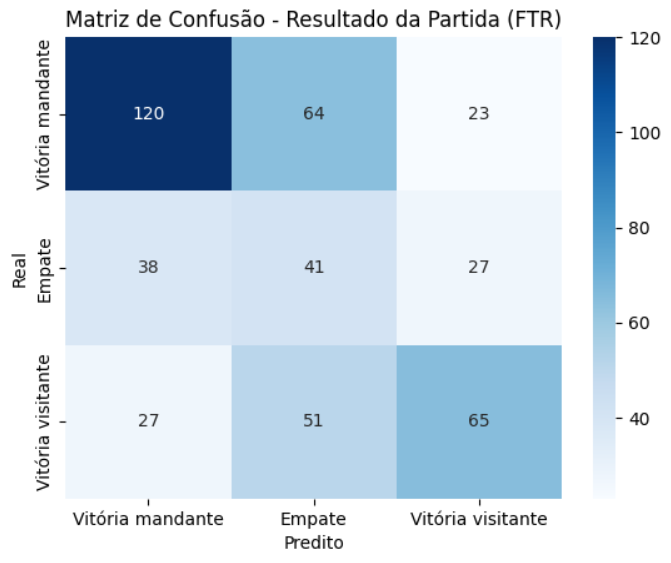

#### **3.3.3 Regressão Logística**

**Objetivo:** Prever o resultado final (FTR) em três classes:
- **H**: Vitória do mandante (Home)
- **D**: Empate (Draw)
- **A**: Vitória do visitante (Away)

##### **3.3.3.1 Tratamento dos Dados de Entrada**

**Feature Engineering:**

1. **Variáveis Criadas:**
   - `Goal_Diff_Home`: Diferença de gols (FTHG - FTAG)
   - `Home_Win`: Variável binária (1 se FTR == 'H', 0 caso contrário)
   - `Home_CumPoints`, `Away_CumPoints`: Pontos acumulados ao longo da temporada
   - `Home_Streak`, `Away_Streak`: Sequência de vitórias/derrotas recentes (momentum)
   - `Home_GF_GA_Ratio`, `Away_GF_GA_Ratio`: Razão gols marcados/sofridos

2. **Normalização de Odds:**
   - Conversão de odds em probabilidades: $$ P = \frac{1}{\text{Odd}} $$
   - Normalização: $$ P_{\text{norm}} = \frac{P}{P_H + P_D + P_A} $$
   - Features: `B365H_prob_norm`, `B365D_prob_norm`, `B365A_prob_norm`

3. **Features Estatísticas:**
   - Médias móveis de chutes, chutes no alvo, escanteios, faltas
   - Cartões acumulados (disciplina)

4. **Encoding e Padronização:**
   - Label Encoding para times (HomeTeam, AwayTeam)
   - StandardScaler para features numéricas

**Divisão dos Dados:**
- **Treino**: 80% (estratificado por FTR)
- **Teste**: 20%
- **Validação Cruzada**: 5-fold Stratified K-Fold

##### **3.3.3.2 Treinamento do modelo**

**Importancia das variáveis**

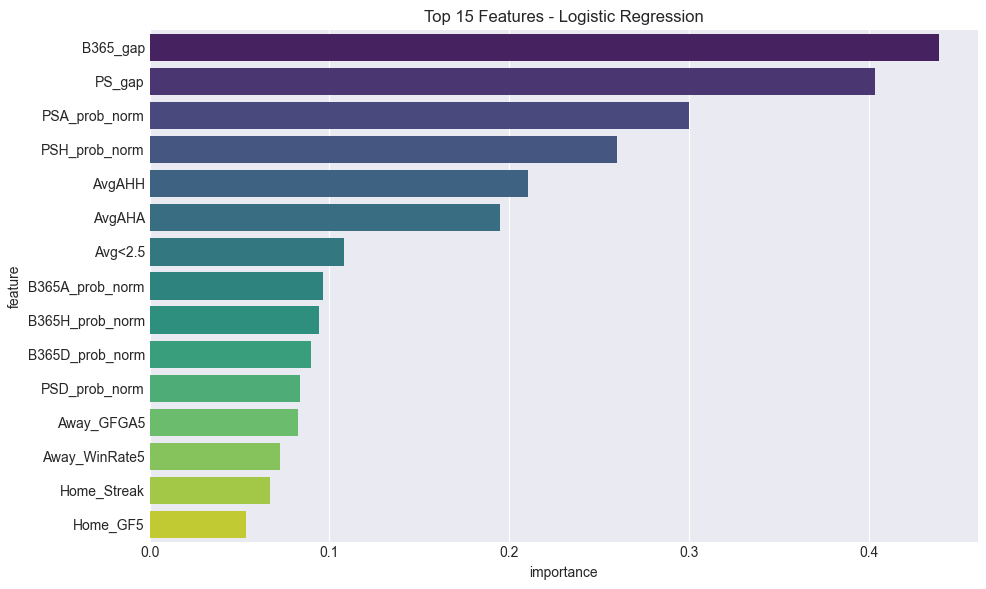

##### **3.3.3.3 Avalicação de métricas** 

**Treinamento e Avaliação — Modelos de Classificação**

---

**Modelo: *Logistic Regression***

- **Acurácia (Treino):** 0.5565  
- **Acurácia (Teste):** 0.5351  
- **Precision:** 0.5478  
- **Recall:** 0.5351  
- **F1-Score:** 0.4717  

**Validação Cruzada (5-fold)**

- **CV Accuracy:** 0.5447 ± 0.0197  
- **Intervalo de Confiança 95%:** [0.5061, 0.5833]

---


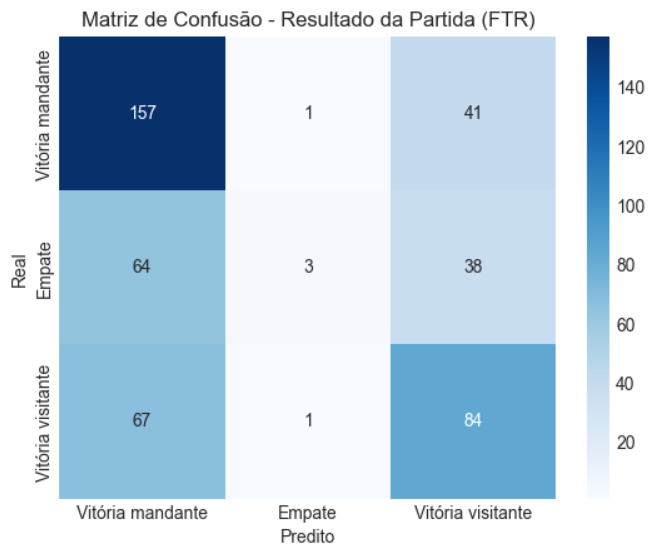

**Por que é tão difícil prever empates?**

A classe empate é, de longe, a mais desafiadora em modelos preditivos de resultados de partidas de futebol. Isso ocorre por uma combinação de fatores estatísticos, estruturais e até mesmo inerentes ao próprio esporte. No caso da regressão logística treinada aqui, vemos novamente esse comportamento: a precisão, o recall e o F1 do empate ficam significativamente abaixo das outras classes. Isso não é falha do modelo, é reflexo da natureza do problema.

Além da baixa frequência, empates são resultados marcados por forte componente de aleatoriedade. Pequenos eventos (uma finalização desperdiçada, um erro individual, uma bola desviada) são suficientes para deslocar o placar para um dos lados. Em termos estatísticos, isso significa que a fronteira entre “empate” e “vitória” é muito mais difusa do que a fronteira entre “vitória do mandante” e “vitória do visitante”. A regressão logística, sendo um modelo linear, depende de relações claras entre os preditores e o alvo; quando o padrão que distingue a classe é fraco, não linear ou altamente sensível a ruído, o modelo tende a errar.

##### **3.3.3.3 Comparativo dos modelos**

A comparação entre os modelos evidencia uma evolução clara na capacidade preditiva à medida que incorporamos mais estrutura e informação ao processo. O modelo aleatório, que serve como baseline, alcança uma acurácia próxima a 33%, refletindo essencialmente o acerto esperado por puro acaso em um problema com três classes. Quando aplicamos regras simples baseadas na probabilidade implícita das odds, particularmente a probabilidade da vitória do mandante, já observamos um salto substancial de desempenho, atingindo cerca de 50% de acurácia. Isso mostra que as odds carregam um sinal importante e relativamente fácil de explorar. 

A regressão logística, por sua vez, ligeiramente supera o modelo de regras, alcançando aproximadamente 53% de acerto no conjunto de teste. Ainda que o ganho em relação às regras seja modesto, ele demonstra que o modelo estatístico consegue capturar padrões adicionais que não são acessíveis por uma lógica de decisão fixa. Em conjunto, os resultados reforçam que o uso de informações de mercado (odds) já fornece um baseline forte, e que metodologias mais complexas podem ampliar esse desempenho, embora com retornos marginais conforme o problema se torna estruturalmente difícil, como é o caso da previsão de empates.

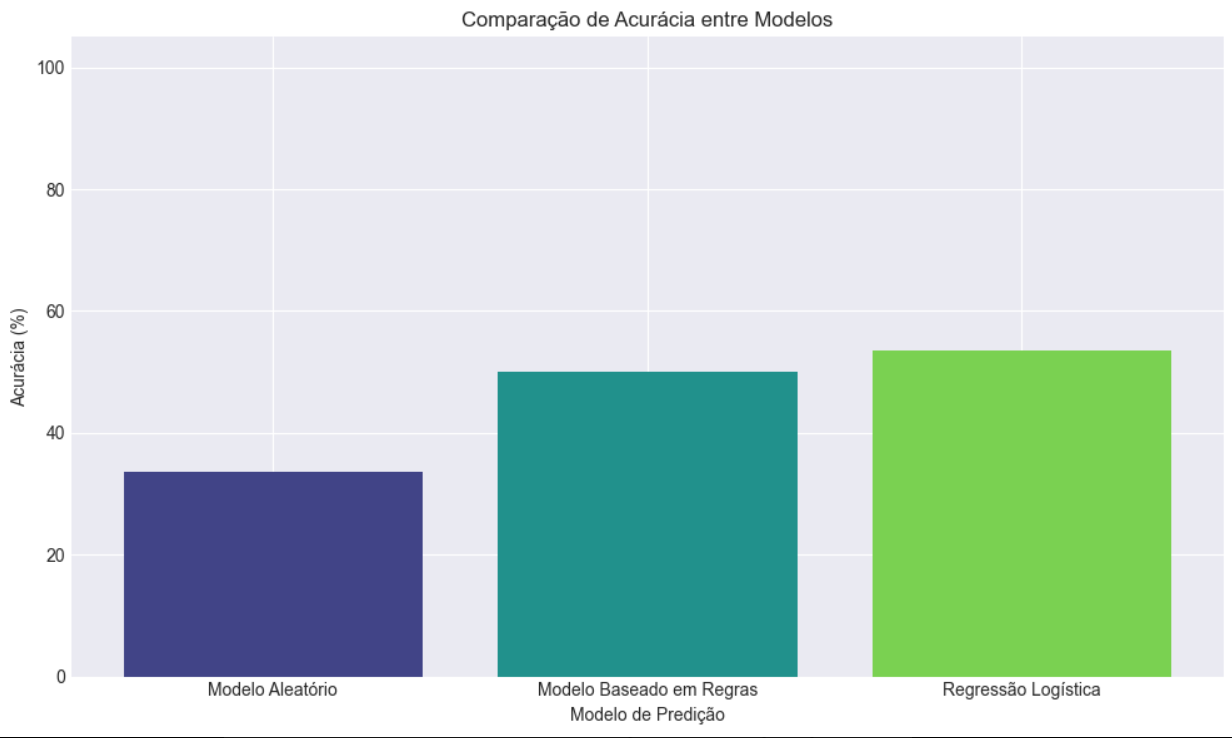

## **4. CONCLUSÃO**

### **4.1 Síntese dos Principais Achados**

Esta análise estatística e preditiva da Premier League (2019-2025) revelou insights fundamentais sobre a dinâmica do futebol profissional e os limites da previsibilidade neste esporte.

**Confirmação do Fator Casa:**  
O estudo quantificou de forma robusta a vantagem do mandante, com **43.6% de vitórias em casa** contra **33.4% de vitórias do visitante**. A diferença média de **0.23 gols** a favor do mandante, acompanhada de maior agressividade ofensiva (+2.16 chutes, +0.69 chutes no alvo), demonstra que jogar em casa continua sendo um fator estatisticamente significativo mesmo no futebol moderno.

**Recalibração das Expectativas sobre Favoritos:**  
O teste de hipótese mais impactante revelou que os times favoritos (identificados pelas menores odds) vencem apenas **55.5%** das partidas, muito abaixo da referência teórica de 70%. Este achado redefine nossa compreensão sobre a previsibilidade da Premier League, confirmando sua reputação como uma das ligas mais competitivas e imprevisíveis do mundo.

**Relação Odds-Resultados:**  
As odds das casas de apostas, quando convertidas em probabilidades normalizadas, demonstraram ser indicadores valiosos. Partidas com favoritos claros (odds de empate altas) resultaram em **0.6 gol a mais** em média e **10.8% menos empates**, evidenciando que o mercado de apostas captura efetivamente o potencial ofensivo das partidas.

### **4.2 Sobre a Previsibilidade do Futebol**

**Limites Estruturais da Predição:**  
Os modelos de machine learning testados atingiram uma acurácia máxima de **53.5%** (regressão logística), representando um ganho modesto sobre regras simples baseadas em odds (49.6%). Este platô de desempenho não reflete limitações técnicas, mas sim a **natureza intrinsecamente aleatória** do futebol.

**O Problema dos Empates:**  
A classe "empate" emergiu como o maior desafio preditivo, com precision e recall consistentemente baixos em todos os modelos. Empates são eventos marcados por alta sensibilidade a fatores aleatórios que não são capturáveis por variáveis estatísticas convencionais.

**Informação vs. Ruído:**  
Mesmo utilizando 85 variáveis detalhadas (odds, estatísticas de jogo, momentum dos times), o ganho preditivo permaneceu limitado. Isso sugere que o futebol opera próximo ao limite teórico de previsibilidade, onde o sinal útil é rapidamente superado pelo ruído inerente à dinâmica complexa de 22 jogadores interagindo em tempo real.

### **4.3 Implicações Práticas**

**Para Análise Esportiva:**  
- As odds normalizadas são features mais informativas que estatísticas detalhadas de jogo
- O fator casa deve ser incorporado em qualquer modelo preditivo
- Modelos complexos oferecem retornos marginais sobre regras simples bem calibradas

**Para o Mercado de Apostas:**  
- A taxa de sucesso de 55% para favoritos deve ser o novo baseline de referência na Premier League
- Estratégias baseadas em modelos preditivos enfrentam limitações estruturais significativas

**Para a Ciência de Dados:**  
- O futebol exemplifica domínios onde a aleatoriedade intrínseca impõe tetos rígidos à capacidade preditiva
- A incorporação de informações de mercado (odds) pode ser mais efetiva que feature engineering extensivo

### **4.4 Reflexão Final**

Este estudo confirma que o futebol, particularmente em ligas altamente competitivas como a Premier League, permanece fundamentalmente imprevisível. A beleza e o apelo global deste esporte residem, em grande parte, nesta incapacidade de reduzir sua complexidade a padrões totalmente previsíveis. 

Embora técnicas de ciência de dados possam extrair insights valiosos e melhorar marginalmente nossa capacidade de antecipação, elas também revelam os limites fundamentais da predição em sistemas complexos. **O futebol não é apenas um jogo de números, mas um fenômeno emergente onde a soma é genuinamente maior que suas partes.**